# Projeto: Análise de Sífilis Congênita em Minas Gerais

**Disciplina:** Análise de Dados  
**Data:** Abril de 2026 | **Versão:** 3.0

---

### Descrição

Este notebook cobre as etapas M1 (Data Engineering), M2 (EDA) e M3 (Modelagem Preditiva) aplicadas ao dataset de notificações de Sífilis Congênita no estado de Minas Gerais, extraído do SINAN. O período analisado vai de 2010 a 2026, com 33.345 registros distribuídos em 853 municípios e 28 regionais de saúde.

O problema central é entender quais fatores — como o momento do diagnóstico materno, a adequação do tratamento e o perfil demográfico — se associam ao desfecho clínico da criança (óbito por sífilis congênita vs. nascido vivo).

### Equipe

| Integrante | RM |
|---|---|
| Gustavo Correia Scarabeli | 082210030 |
| Matheus Andrade de Oliveira | 082210020 |
| Artur Rossi Junior | 082210044 |
| Gustavo Correa Pedro de Carvalho | 082210018 |

### Stack

- **Linguagem:** Python 3.x
- **Bibliotecas:** Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn, Joblib
- **Ambiente:** Google Colab + Google Drive
- **Fonte:** SINAN — Sífilis Congênita / Minas Gerais

### Estrutura de pastas esperada no Drive

```
MyDrive/ANALDA_Sifilis_MG/
├── data/
│   ├── raw/
│   └── processed/
└── models/
```

---

---
# M1 — Data Engineering
---

## Objetivo

Construir um pipeline ETL sobre os dados brutos do SINAN-MG, aplicando limpeza, padronização e modelagem dimensional em Star Schema. Os artefatos gerados aqui alimentam diretamente as etapas de EDA e modelagem preditiva.

## Arquitetura — Star Schema

```
                   dim_tempo
                  (id_tempo)
                      |
   dim_local ---- fato_casos ---- dim_paciente
  (id_local)    (id_fato, FKs,   (id_paciente)
                 medidas)             |
                      |          dim_clinico
                 dim_clinico     (id_clinico)
```

**Tabela Fato:** `fato_casos` — uma linha por notificação, com chaves estrangeiras para as quatro dimensões e as métricas/flags de desfecho.

**Dimensões:**
- `dim_tempo`: ano, mês, trimestre da notificação
- `dim_local`: município de notificação, regional de saúde
- `dim_paciente`: sexo, raça/cor, faixa etária
- `dim_clinico`: momento do diagnóstico materno, esquema de tratamento, IgG

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE = '/content/drive/MyDrive/DATA_STORM_Project'
for d in [f'{BASE}/data/raw', f'{BASE}/data/processed', f'{BASE}/models']:
    os.makedirs(d, exist_ok=True)

print('Drive montado e diretórios criados.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado e diretórios criados.


In [11]:
!pip install -q pyarrow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import joblib
import time
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

## Extract

O arquivo foi obtido diretamente do SINAN/DATASUS, referente às notificações de Sífilis Congênita (CID A509) registradas em Minas Gerais entre 2010 e 2026. O separador é ponto e vírgula e a codificação é UTF-8 com BOM.

In [12]:
# Ajuste o caminho abaixo para onde você fez upload do arquivo no seu Drive
RAW_FILE = '/content/drive/MyDrive/DATA_STORM_Project/data/raw/Dados_MG_Sifilis.csv'

# Se ainda não copiou o arquivo para o Drive, faça upload diretamente:
# from google.colab import files
# uploaded = files.upload()  # selecione Dados_MG_-_Siflis.csv
# import shutil
# shutil.copy(list(uploaded.keys())[0], RAW_FILE)

df_raw = pd.read_csv(RAW_FILE, sep=';', encoding='utf-8-sig', low_memory=False)

print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (33345, 16)


,id_agravo,dt_notific,nu_ano,id_municip,id_regiona,dt_diag,dt_nasc,nu_idade_n,cs_sexo,cs_raca,id_mn_resi,id_rg_resi,antsifil_n,tra_esquem,labc_igg,evolucao
0,A509,2019-01-24,2019,MONTES CLAROS,MONTES CLAROS,2019-01-23,2019-01-23,"0,0",Masculino,Parda,FRANCISCO SÁ,MONTES CLAROS,No momento do parto/curetagem,Adequado,Não realizado,Vivo
1,A509,2019-03-26,2019,MONTES CLAROS,MONTES CLAROS,2019-03-25,2019-03-25,"0,0",Masculino,Branca,MONTES CLAROS,MONTES CLAROS,Durante o pré-natal,Inadequado,Não se aplica,Vivo
2,A509,2018-02-23,2018,MONTES CLAROS,MONTES CLAROS,2018-02-23,2015-08-22,"2,0",Feminino,Parda,MONTES CLAROS,MONTES CLAROS,No momento do parto/curetagem,Não realizado,Ignorado,Vivo
3,A509,2018-02-22,2018,MONTES CLAROS,MONTES CLAROS,2018-02-22,2017-01-14,"1,0",Masculino,Parda,MONTES CLAROS,MONTES CLAROS,Durante o pré-natal,Inadequado,Não realizado,Vivo
4,A509,2019-03-15,2019,MONTES CLAROS,MONTES CLAROS,2019-03-15,2019-03-13,"0,0",Masculino,Parda,MONTES CLAROS,MONTES CLAROS,Durante o pré-natal,Inadequado,Não se aplica,Vivo


In [13]:
# Visão geral da qualidade dos dados brutos
print(f'Registros: {len(df_raw):,}')
print(f'Colunas:   {df_raw.shape[1]}')
print(f'Período:   {df_raw["nu_ano"].min()} – {df_raw["nu_ano"].max()}')
print()

nulos = df_raw.isnull().sum()
nulos_pct = (nulos / len(df_raw) * 100).round(2)
resumo = pd.DataFrame({'Nulos': nulos, '% Nulo': nulos_pct})
print(resumo[resumo['Nulos'] > 0].to_string())

Registros: 33,345
Colunas:   16
Período:   2010 – 2026

            Nulos  % Nulo
id_municip     43    0.13
id_regiona     43    0.13
dt_nasc         2    0.01
nu_idade_n      2    0.01
cs_sexo      1389    4.17
cs_raca       500    1.50
id_mn_resi      2    0.01
id_rg_resi  14669   43.99
antsifil_n      1    0.00
tra_esquem      1    0.00
labc_igg      592    1.78


## Transform

**Decisões de engenharia tomadas:**

1. `nu_idade_n` usa vírgula como separador decimal — convertida para float e depois para int (anos).
2. Valores nulos em variáveis categóricas são preenchidos com `'Ignorado'`, categoria já prevista no SINAN, evitando perda de registros.
3. Municípios nulos (43 registros, ~0,13%) são preenchidos com `'Não informado'` — volume irrelevante para análise regional.
4. `id_rg_resi` tem ~44% de nulos; a coluna é mantida apenas nas dimensões onde faz sentido e excluída da modelagem.
5. A variável `evolucao` é reagrupada em três categorias para o target: `Vivo`, `Obito_Sifilis` e `Outro_Desfecho`.
6. Datas convertidas para `datetime`; criadas colunas derivadas de mês e trimestre.

In [14]:
df = df_raw.copy()

# Converter idade (vírgula → ponto)
df['nu_idade_n'] = df['nu_idade_n'].astype(str).str.replace(',', '.').astype(float).fillna(0).astype(int)

# Datas
for col in ['dt_notific', 'dt_diag', 'dt_nasc']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['mes_notific'] = df['dt_notific'].dt.month
df['trimestre']   = df['dt_notific'].dt.quarter.apply(lambda q: f'Q{q}')

# Preencher nulos categóricos
cat_fill = ['cs_sexo', 'cs_raca', 'id_municip', 'id_regiona',
            'id_mn_resi', 'antsifil_n', 'tra_esquem', 'labc_igg']
for col in cat_fill:
    df[col] = df[col].fillna('Ignorado')

df['id_rg_resi'] = df['id_rg_resi'].fillna('Não informado')

# Faixa etária (a maioria tem 0 anos — recém-nascidos; faixas ampliam para capturar casos raros)
df['faixa_etaria'] = pd.cut(
    df['nu_idade_n'],
    bins=[-1, 0, 1, 2, 5, 100],
    labels=['0 anos', '1 ano', '2 anos', '3–5 anos', '6+ anos']
).astype(str)

# Target binário: óbito por sífilis congênita
df['obito_sifilis'] = (df['evolucao'] == 'Óbito por sífilis congênita').astype(int)

print(f'Transformação concluída. Shape: {df.shape}')
print(f'Nulos restantes: {df.isnull().sum().sum()}')
print()
print('Distribuição do target (obito_sifilis):')
print(df['obito_sifilis'].value_counts())

Transformação concluída. Shape: (33345, 20)
Nulos restantes: 2

Distribuição do target (obito_sifilis):
obito_sifilis
0    32897
1      448
Name: count, dtype: int64


## Modelagem Dimensional — Star Schema

In [15]:
# dim_tempo
dim_tempo = df[['nu_ano', 'mes_notific', 'trimestre']].drop_duplicates().copy()
dim_tempo = dim_tempo.sort_values(['nu_ano', 'mes_notific']).reset_index(drop=True)
dim_tempo.insert(0, 'id_tempo', dim_tempo.index + 1)
dim_tempo.columns = ['id_tempo', 'ano', 'mes', 'trimestre']

# dim_local
dim_local = df[['id_municip', 'id_regiona']].drop_duplicates().copy().reset_index(drop=True)
dim_local.insert(0, 'id_local', dim_local.index + 1)
dim_local.columns = ['id_local', 'municipio', 'regional']

# dim_paciente
dim_paciente = df[['cs_sexo', 'cs_raca', 'faixa_etaria']].drop_duplicates().copy().reset_index(drop=True)
dim_paciente.insert(0, 'id_paciente', dim_paciente.index + 1)
dim_paciente.columns = ['id_paciente', 'sexo', 'raca_cor', 'faixa_etaria']

# dim_clinico
dim_clinico = df[['antsifil_n', 'tra_esquem', 'labc_igg']].drop_duplicates().copy().reset_index(drop=True)
dim_clinico.insert(0, 'id_clinico', dim_clinico.index + 1)
dim_clinico.columns = ['id_clinico', 'momento_diag_materno', 'esquema_tratamento', 'labc_igg']

# fato_casos
df_fato = df.merge(dim_tempo,    left_on=['nu_ano','mes_notific','trimestre'], right_on=['ano','mes','trimestre'], how='left')\
            .merge(dim_local,    left_on=['id_municip','id_regiona'],          right_on=['municipio','regional'],  how='left')\
            .merge(dim_paciente, left_on=['cs_sexo','cs_raca','faixa_etaria'], right_on=['sexo','raca_cor','faixa_etaria'], how='left')\
            .merge(dim_clinico,  left_on=['antsifil_n','tra_esquem','labc_igg'], right_on=['momento_diag_materno','esquema_tratamento','labc_igg'], how='left')

df_fato = df_fato[['id_tempo','id_local','id_paciente','id_clinico',
                    'nu_idade_n','obito_sifilis','evolucao']].copy()
df_fato.insert(0, 'id_fato', range(1, len(df_fato)+1))

print('Star Schema — resumo das tabelas:')
print(f'  fato_casos:    {df_fato.shape}')
print(f'  dim_tempo:     {dim_tempo.shape}')
print(f'  dim_local:     {dim_local.shape}')
print(f'  dim_paciente:  {dim_paciente.shape}')
print(f'  dim_clinico:   {dim_clinico.shape}')

Star Schema — resumo das tabelas:
  fato_casos:    (33345, 8)
  dim_tempo:     (195, 4)
  dim_local:     (422, 3)
  dim_paciente:  (55, 4)
  dim_clinico:   (95, 4)


## Load

Os dados brutos são persistidos em CSV na camada `raw`. As tabelas do Star Schema são salvas em Parquet na camada `processed`, formato colunar otimizado para leitura analítica.

In [16]:
RAW_PATH  = f'{BASE}/data/raw'
PROC_PATH = f'{BASE}/data/processed'

# Raw
df_raw.to_csv(f'{RAW_PATH}/sifilis_mg_bruto.csv', index=False)

# Processed — Star Schema
tabelas = {
    'fato_casos':   df_fato,
    'dim_tempo':    dim_tempo,
    'dim_local':    dim_local,
    'dim_paciente': dim_paciente,
    'dim_clinico':  dim_clinico,
}
for nome, tabela in tabelas.items():
    tabela.to_parquet(f'{PROC_PATH}/{nome}.parquet', index=False)
    print(f'Salvo: {nome}.parquet ({len(tabela):,} registros)')

print('\nLoad concluído.')

Salvo: fato_casos.parquet (33,345 registros)
Salvo: dim_tempo.parquet (195 registros)
Salvo: dim_local.parquet (422 registros)
Salvo: dim_paciente.parquet (55 registros)
Salvo: dim_clinico.parquet (95 registros)

Load concluído.


---
# M2 — Exploratory Data Analysis
---

## Objetivo

Compreender a estrutura dos dados antes de qualquer decisão de modelagem. A análise está organizada em três blocos: estatística descritiva e univariada, análise multivariada/correlação e visualizações que sustentam as conclusões.

In [17]:
# Dataset analítico — join fato + dimensões
df_eda = df_fato.merge(dim_tempo,    on='id_tempo')\
                .merge(dim_local,    on='id_local')\
                .merge(dim_paciente, on='id_paciente')\
                .merge(dim_clinico,  on='id_clinico')

print(f'Dataset para EDA: {df_eda.shape}')
df_eda.head(3)

Dataset para EDA: (33345, 19)


,id_fato,id_tempo,id_local,id_paciente,id_clinico,nu_idade_n,obito_sifilis,evolucao,ano,mes,trimestre,municipio,regional,sexo,raca_cor,faixa_etaria,momento_diag_materno,esquema_tratamento,labc_igg
0,1,109,1,1,1,0,0,Vivo,2019,1,Q1,MONTES CLAROS,MONTES CLAROS,Masculino,Parda,0 anos,No momento do parto/curetagem,Adequado,Não realizado
1,2,111,1,2,2,0,0,Vivo,2019,3,Q1,MONTES CLAROS,MONTES CLAROS,Masculino,Branca,0 anos,Durante o pré-natal,Inadequado,Não se aplica
2,3,98,1,3,3,2,0,Vivo,2018,2,Q1,MONTES CLAROS,MONTES CLAROS,Feminino,Parda,2 anos,No momento do parto/curetagem,Não realizado,Ignorado


## A. Estatística Descritiva e Análise Univariada

In [18]:
# Medidas para a variável numérica principal (idade em anos)
s = df_eda['nu_idade_n']

Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
IQR = Q3 - Q1

desc = pd.Series({
    'Média':        round(s.mean(), 4),
    'Mediana':      round(s.median(), 4),
    'Moda':         round(s.mode()[0], 4),
    'Desvio Padrão':round(s.std(), 4),
    'Variância':    round(s.var(), 4),
    'Mínimo':       s.min(),
    'Máximo':       s.max(),
    'Q1':           Q1,
    'Q3':           Q3,
    'IQR':          round(IQR, 4),
    'Skewness':     round(s.skew(), 4),
    'Curtose':      round(s.kurtosis(), 4),
})

print('Estatísticas — Idade (anos):')
print(desc.to_string())
print()

# Outliers — Z-Score
z = np.abs(stats.zscore(s.dropna()))
print(f'Outliers Z-Score > 3: {(z > 3).sum()} registros ({(z > 3).mean()*100:.2f}%)')

# Outliers — IQR
out_iqr = ((s < Q1 - 1.5*IQR) | (s > Q3 + 1.5*IQR)).sum()
print(f'Outliers IQR:          {out_iqr} registros ({out_iqr/len(s)*100:.2f}%)')
print('Decisão: manter — idades acima de 0 são casos tardios ou erros de digitação pontuais.')

Estatísticas — Idade (anos):
Média               0.0233
Mediana             0.0000
Moda                0.0000
Desvio Padrão       0.3756
Variância           0.1411
Mínimo              0.0000
Máximo             39.0000
Q1                  0.0000
Q3                  0.0000
IQR                 0.0000
Skewness           46.9708
Curtose          3809.0107

Outliers Z-Score > 3: 129 registros (0.39%)
Outliers IQR:          364 registros (1.09%)
Decisão: manter — idades acima de 0 são casos tardios ou erros de digitação pontuais.


In [19]:
# Estatísticas para o target e a variável binária de desfecho
print('Distribuição de evolucao:')
print(df_eda['evolucao'].value_counts().to_string())
print()
print('Distribuição de obito_sifilis (target):')
vc = df_eda['obito_sifilis'].value_counts()
print(vc)
print(f'Taxa de óbito por sífilis: {vc[1]/len(df_eda)*100:.2f}%')

Distribuição de evolucao:
evolucao
Vivo                           30000
Ignorado                        1305
Natimorto                        766
Aborto                           575
Óbito por sífilis congênita      448
Óbito por outras causas          251

Distribuição de obito_sifilis (target):
obito_sifilis
0    32897
1      448
Name: count, dtype: int64
Taxa de óbito por sífilis: 1.34%


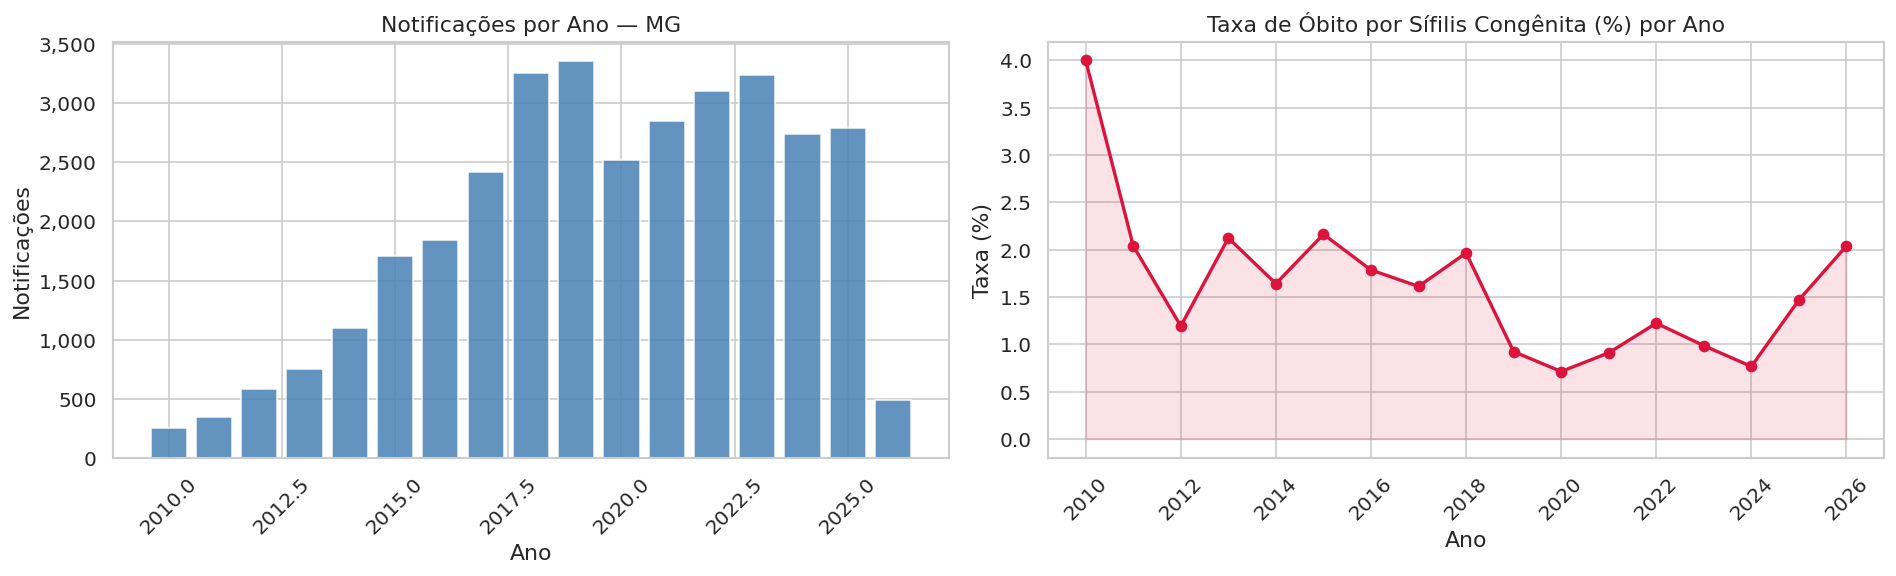

In [20]:
# Evolução temporal dos casos
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

casos_ano = df_eda.groupby('ano').size()
axes[0].bar(casos_ano.index, casos_ano.values, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Notificações por Ano — MG')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Notificações')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].tick_params(axis='x', rotation=45)

taxa_obito_ano = df_eda.groupby('ano')['obito_sifilis'].mean() * 100
axes[1].plot(taxa_obito_ano.index, taxa_obito_ano.values, marker='o',
             color='crimson', linewidth=2, markersize=6)
axes[1].fill_between(taxa_obito_ano.index, taxa_obito_ano.values, alpha=0.12, color='crimson')
axes[1].set_title('Taxa de Óbito por Sífilis Congênita (%) por Ano')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Taxa (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{PROC_PATH}/fig_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

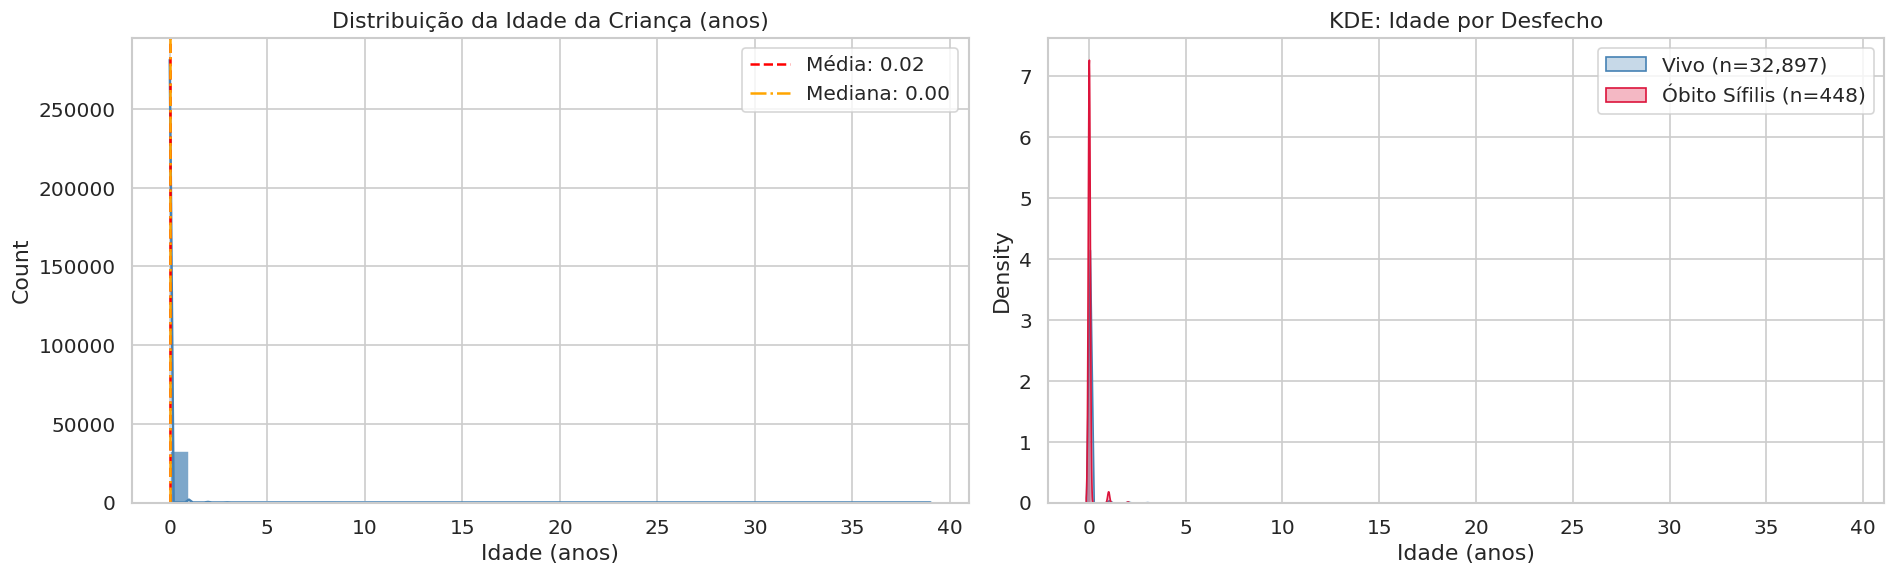

In [21]:
# Histograma + KDE da idade
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df_eda['nu_idade_n'], bins=range(0, 15), kde=True,
             ax=axes[0], color='steelblue', alpha=0.7)
axes[0].axvline(s.mean(),   color='red',    linestyle='--', label=f'Média: {s.mean():.2f}')
axes[0].axvline(s.median(), color='orange', linestyle='-.', label=f'Mediana: {s.median():.2f}')
axes[0].set_title('Distribuição da Idade da Criança (anos)')
axes[0].set_xlabel('Idade (anos)')
axes[0].legend()

for val, label, cor in [(0, 'Vivo', 'steelblue'), (1, 'Óbito Sífilis', 'crimson')]:
    subset = df_eda[df_eda['obito_sifilis'] == val]['nu_idade_n']
    sns.kdeplot(subset, ax=axes[1], label=f'{label} (n={len(subset):,})',
                fill=True, alpha=0.3, color=cor)
axes[1].set_title('KDE: Idade por Desfecho')
axes[1].set_xlabel('Idade (anos)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{PROC_PATH}/fig_idade_distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()

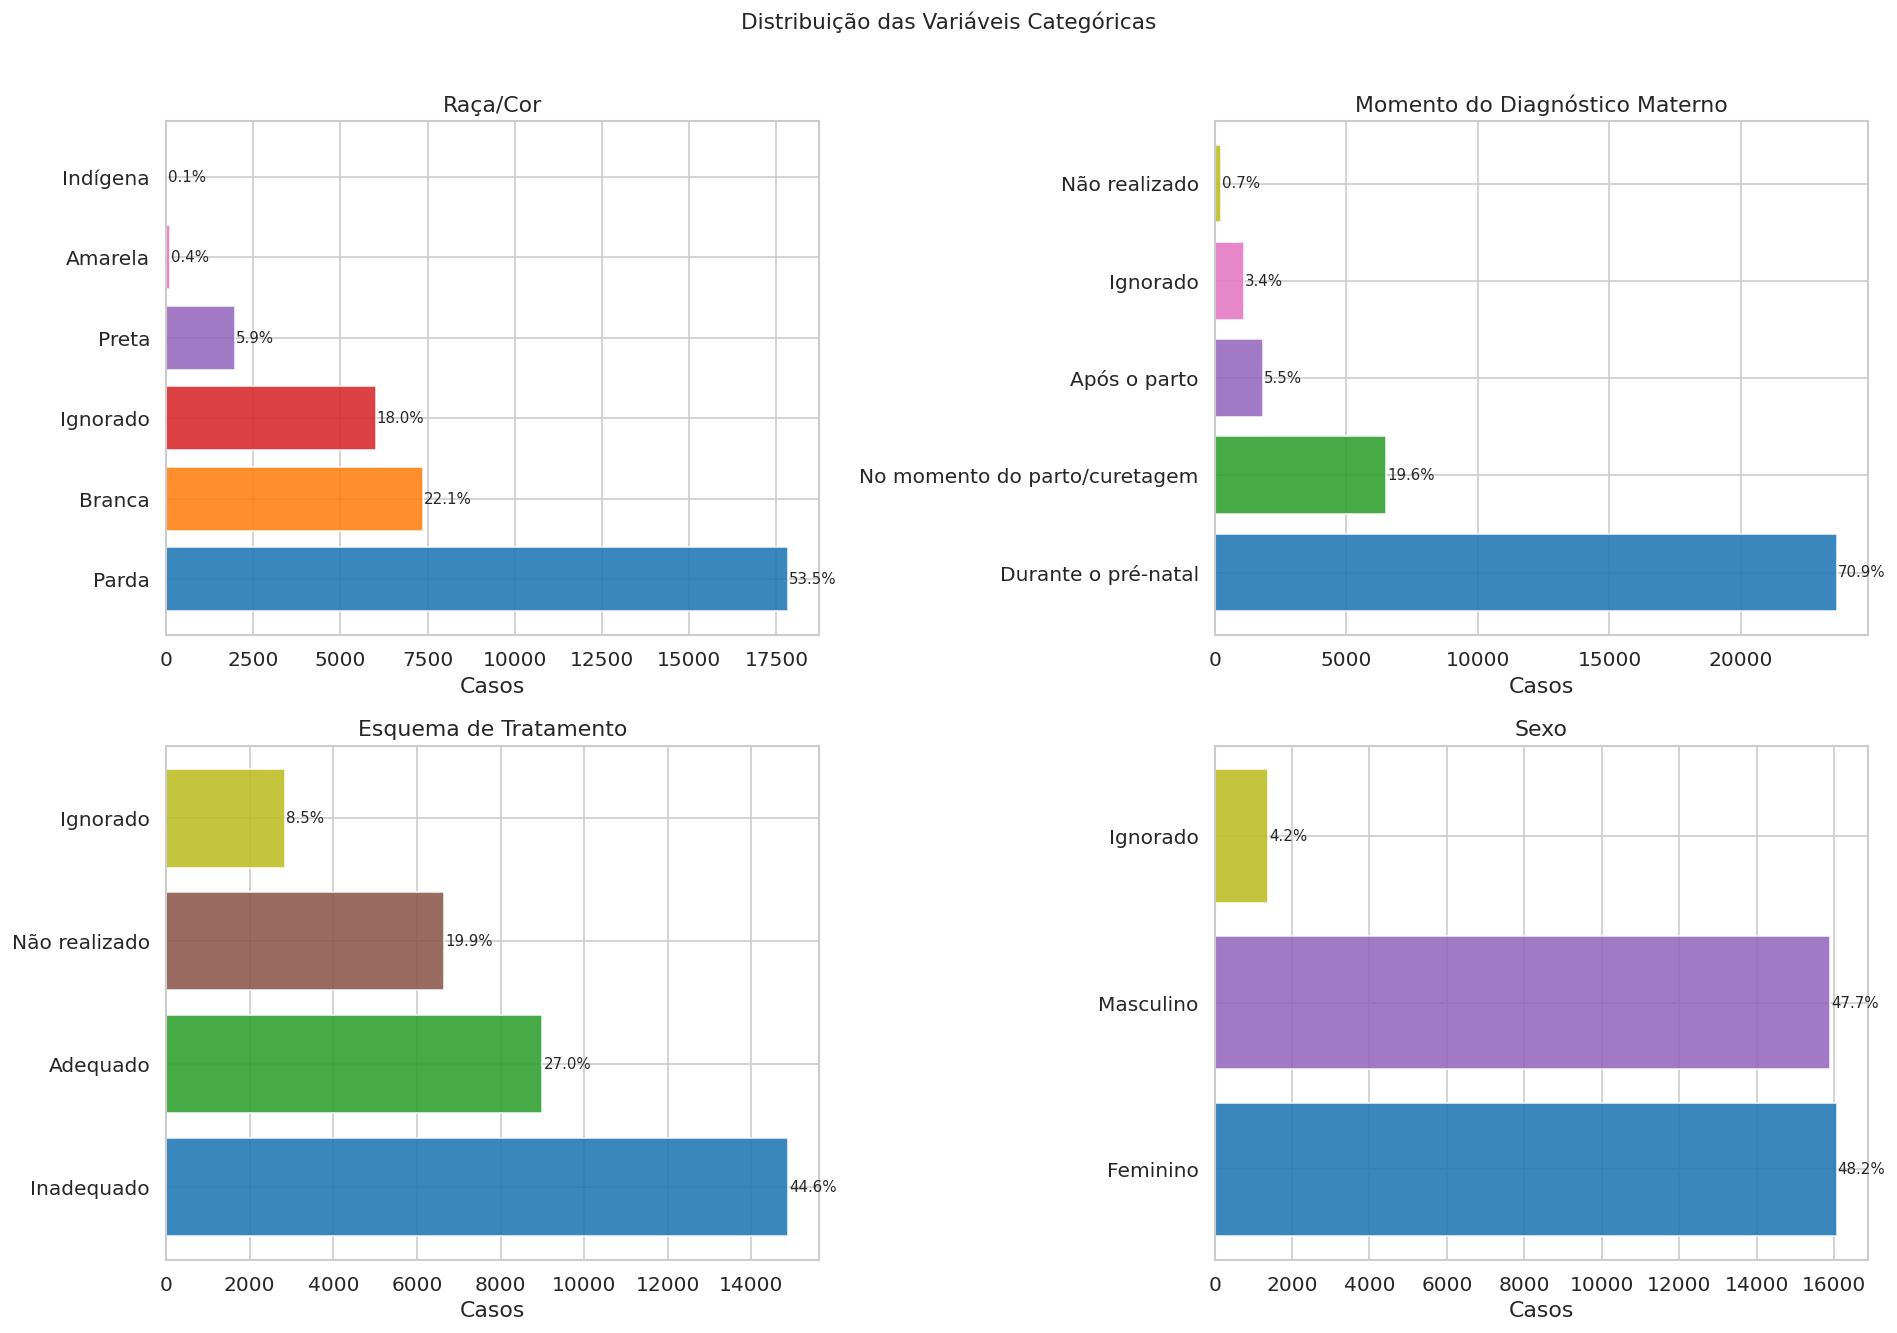

In [22]:
# Variáveis categóricas — distribuição
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

cats = [
    ('raca_cor',              'Raça/Cor'),
    ('momento_diag_materno',  'Momento do Diagnóstico Materno'),
    ('esquema_tratamento',    'Esquema de Tratamento'),
    ('sexo',                  'Sexo'),
]

for ax, (col, title) in zip(axes, cats):
    counts = df_eda[col].value_counts()
    pcts   = counts / len(df_eda) * 100
    colors = plt.cm.tab10(np.linspace(0, 0.8, len(counts)))
    bars = ax.barh(counts.index, counts.values, color=colors, edgecolor='white', alpha=0.88)
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=9)
    ax.set_title(title)
    ax.set_xlabel('Casos')

plt.suptitle('Distribuição das Variáveis Categóricas', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{PROC_PATH}/fig_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

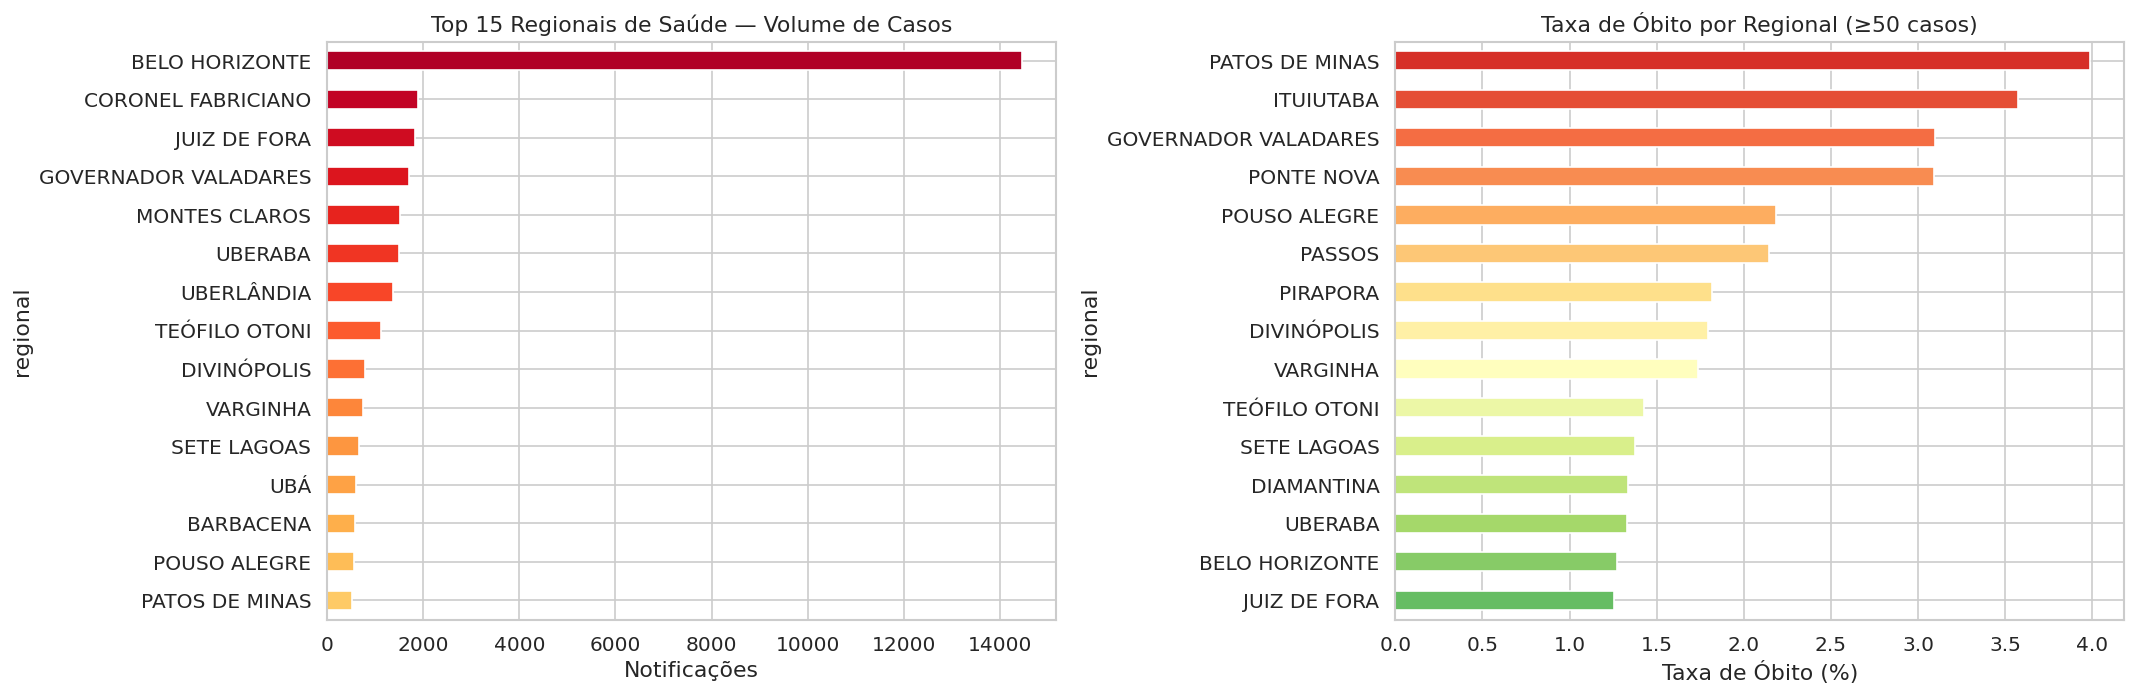

In [23]:
# Top regionais com mais casos
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_reg = df_eda.groupby('regional').size().sort_values(ascending=True).tail(15)
cores = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(top_reg)))
top_reg.plot(kind='barh', ax=axes[0], color=cores, edgecolor='white')
axes[0].set_title('Top 15 Regionais de Saúde — Volume de Casos')
axes[0].set_xlabel('Notificações')

# Taxa de óbito por regional (mínimo 50 casos para estabilidade)
reg_stats = df_eda.groupby('regional').agg(
    casos=('obito_sifilis', 'count'),
    taxa=('obito_sifilis', lambda x: x.mean() * 100)
).query('casos >= 50').sort_values('taxa', ascending=True).tail(15)

cores2 = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(reg_stats)))
reg_stats['taxa'].plot(kind='barh', ax=axes[1], color=cores2, edgecolor='white')
axes[1].set_title('Taxa de Óbito por Regional (≥50 casos)')
axes[1].set_xlabel('Taxa de Óbito (%)')

plt.tight_layout()
plt.savefig(f'{PROC_PATH}/fig_regionais.png', dpi=150, bbox_inches='tight')
plt.show()

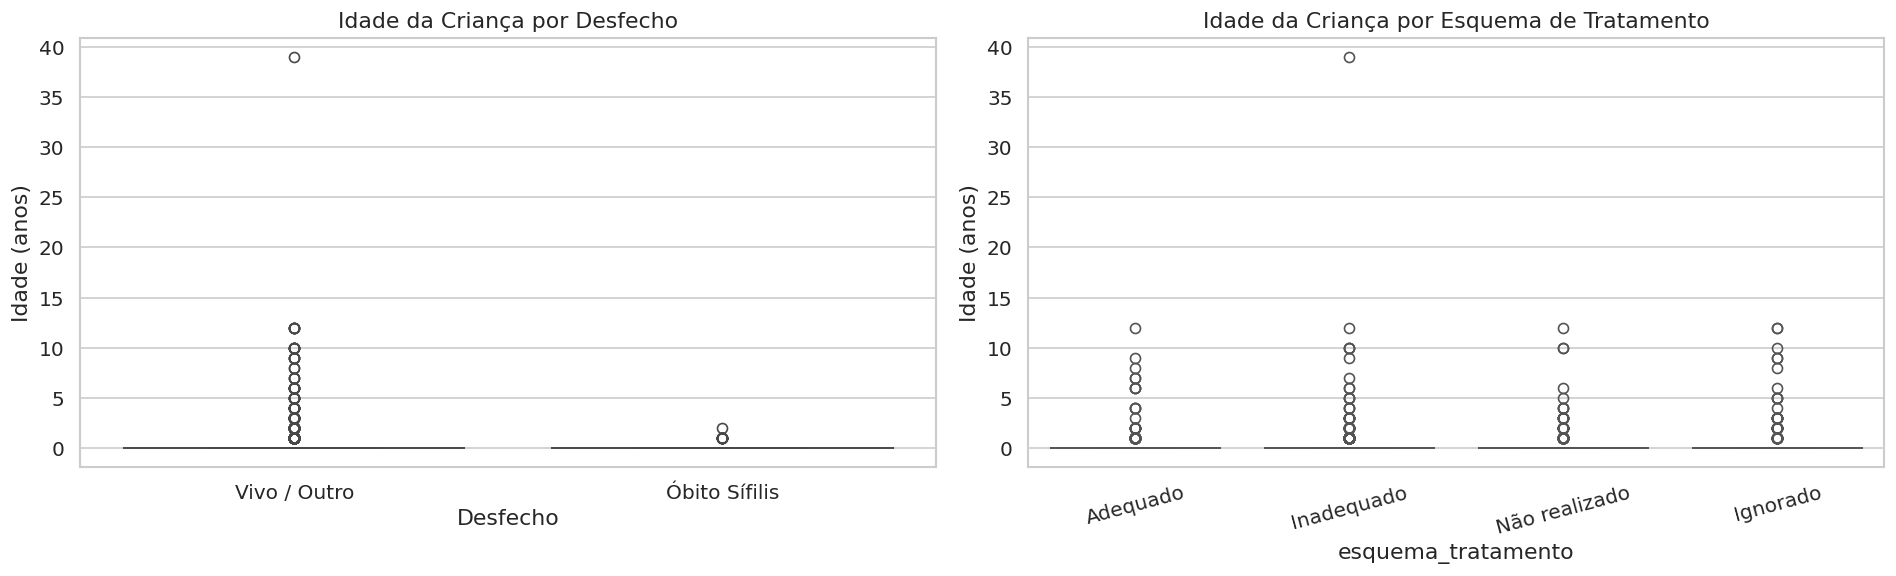

In [24]:
# Boxplot — idade por desfecho e por esquema de tratamento
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_box = df_eda.copy()
df_box['Desfecho'] = df_box['obito_sifilis'].map({0: 'Vivo / Outro', 1: 'Óbito Sífilis'})

sns.boxplot(data=df_box, x='Desfecho', y='nu_idade_n',
            palette={'Vivo / Outro': 'steelblue', 'Óbito Sífilis': 'crimson'}, ax=axes[0])
axes[0].set_title('Idade da Criança por Desfecho')
axes[0].set_ylabel('Idade (anos)')

ordem_trat = ['Adequado', 'Inadequado', 'Não realizado', 'Ignorado']
sns.boxplot(data=df_eda[df_eda['esquema_tratamento'].isin(ordem_trat)],
            x='esquema_tratamento', y='nu_idade_n',
            order=ordem_trat, palette='muted', ax=axes[1])
axes[1].set_title('Idade da Criança por Esquema de Tratamento')
axes[1].set_ylabel('Idade (anos)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f'{PROC_PATH}/fig_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## B. Análise Multivariada e Correlação

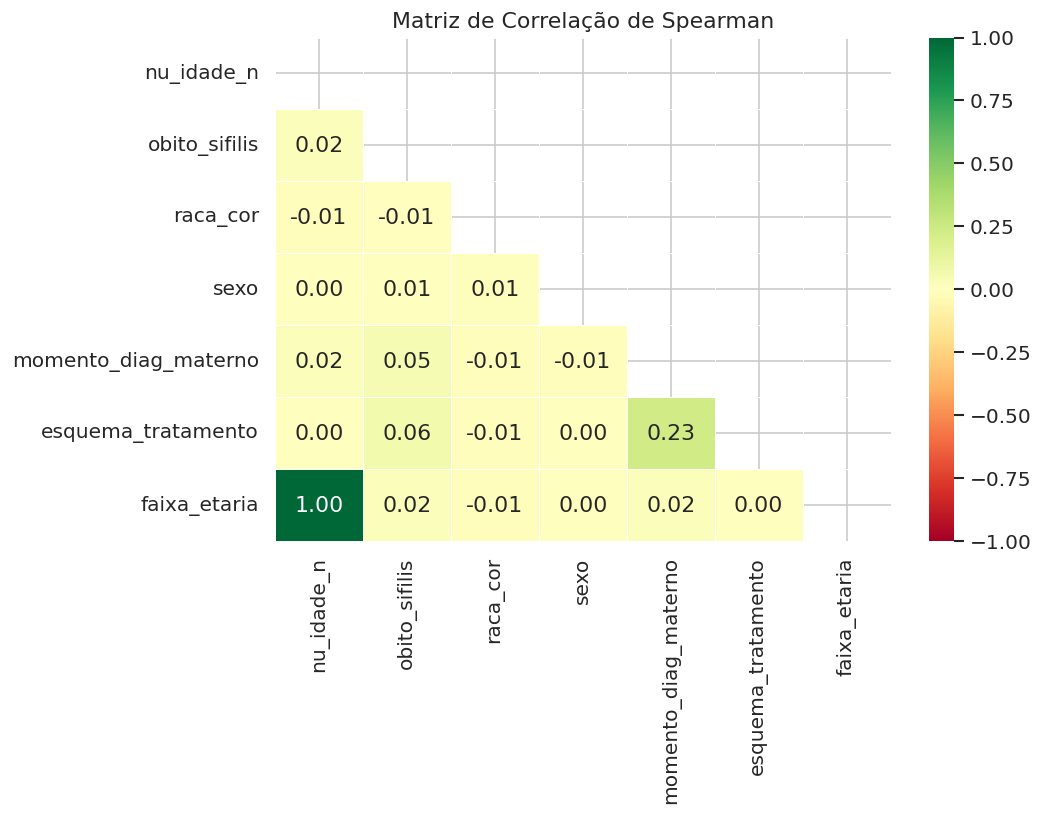

Correlação com o target (obito_sifilis):
esquema_tratamento      0.063857
momento_diag_materno    0.054585
faixa_etaria            0.017728
nu_idade_n              0.017728
sexo                    0.005983
raca_cor               -0.005263


In [25]:
from sklearn.preprocessing import LabelEncoder

df_corr = df_eda[['nu_idade_n', 'obito_sifilis',
                   'raca_cor', 'sexo', 'momento_diag_materno',
                   'esquema_tratamento', 'faixa_etaria']].copy()

le = LabelEncoder()
for col in ['raca_cor', 'sexo', 'momento_diag_materno', 'esquema_tratamento', 'faixa_etaria']:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

corr = df_corr.corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlação de Spearman')
plt.tight_layout()
plt.savefig(f'{PROC_PATH}/fig_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlação com o target (obito_sifilis):')
print(corr['obito_sifilis'].drop('obito_sifilis').sort_values(key=abs, ascending=False).to_string())

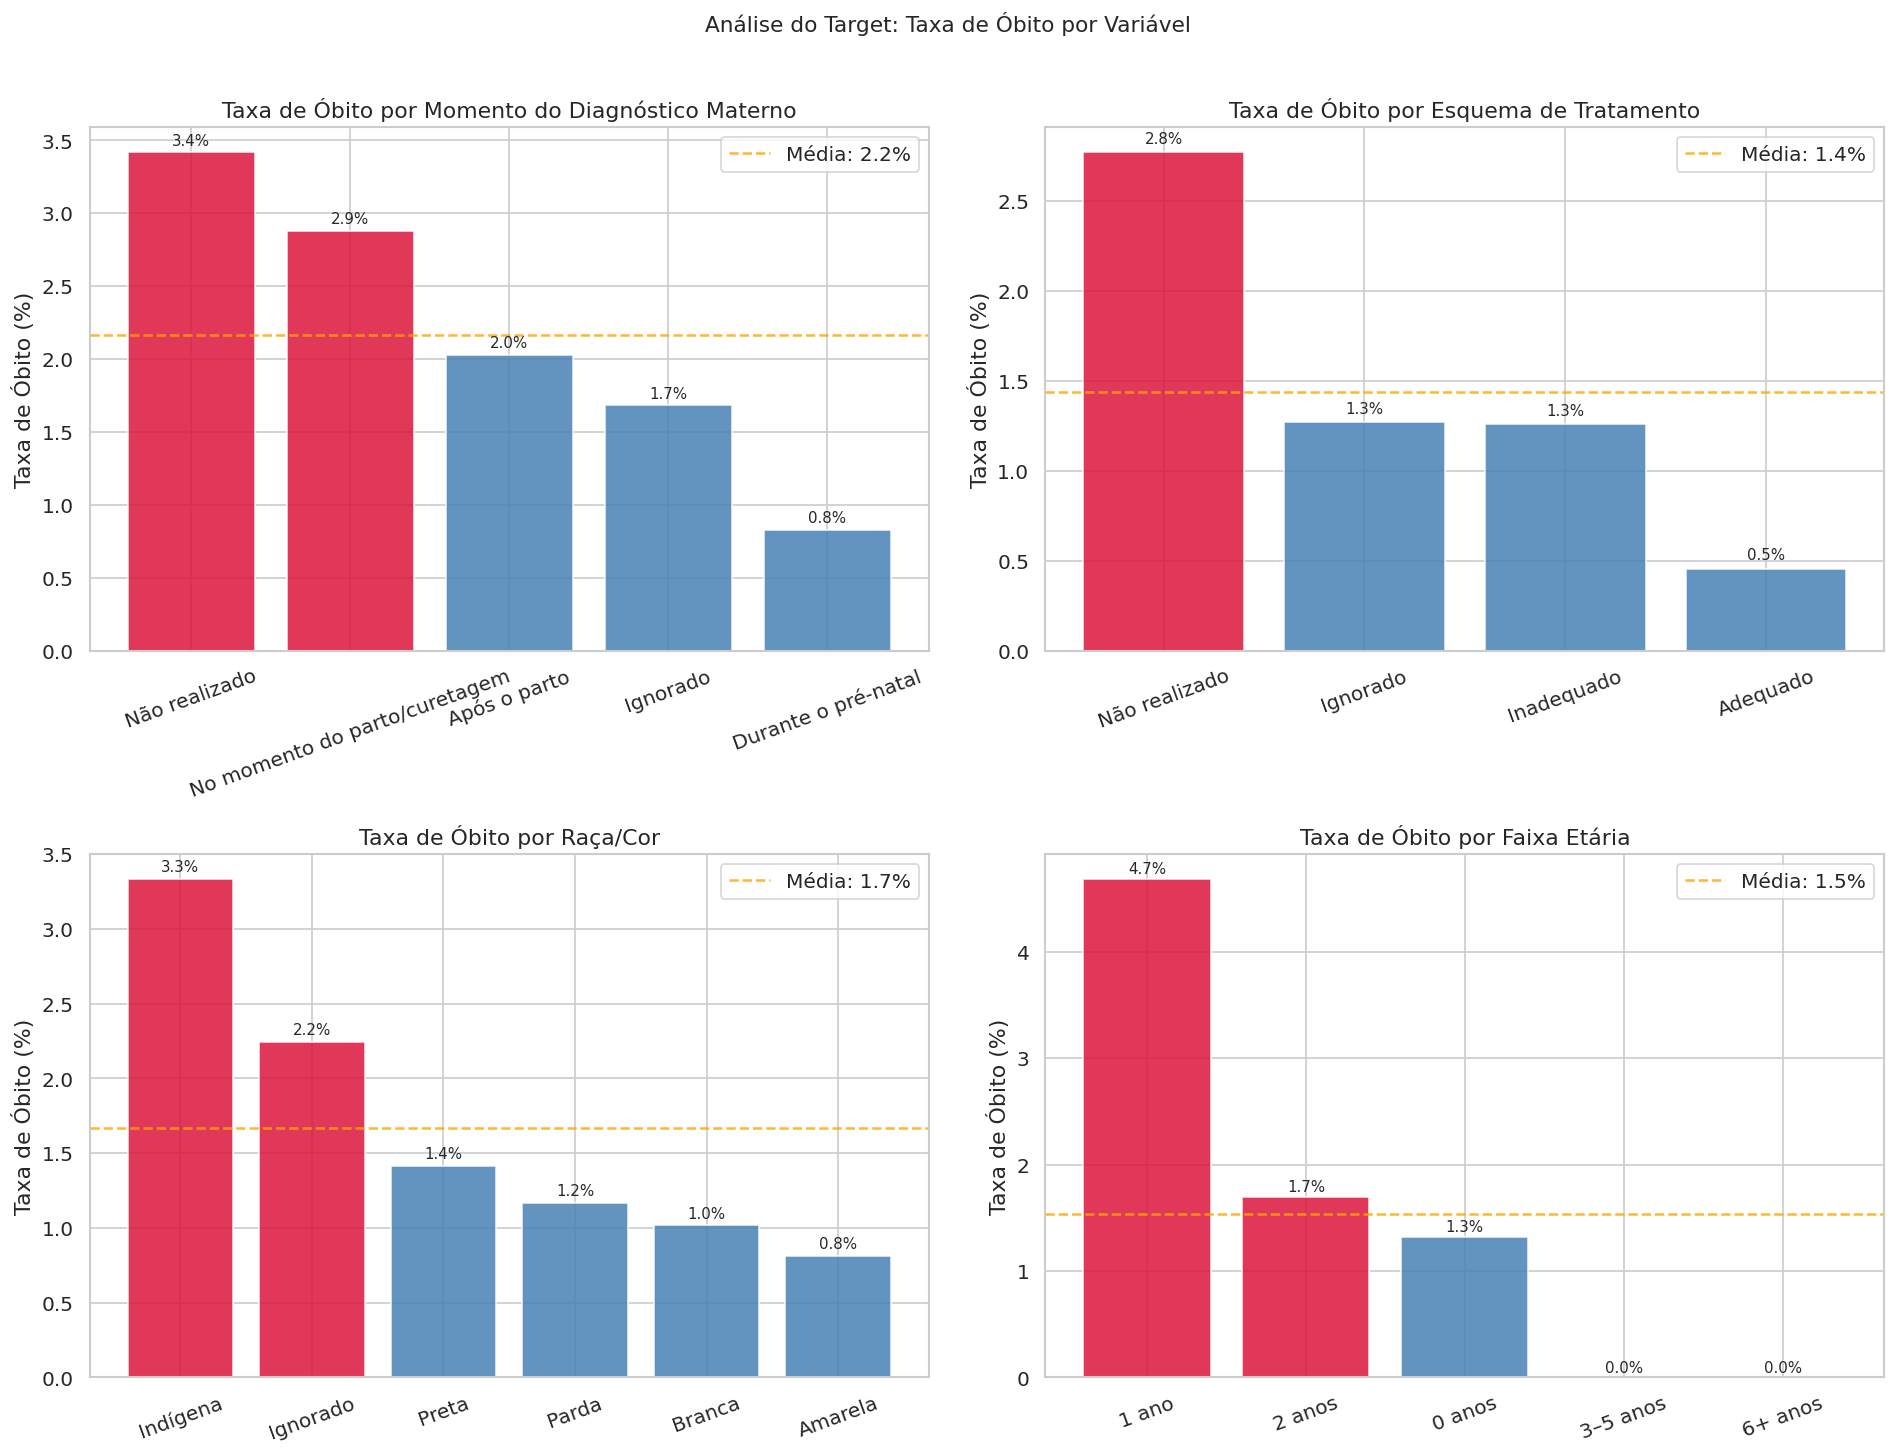

In [26]:
# Taxa de óbito por cada variável categórica
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

analises = [
    ('momento_diag_materno', 'Momento do Diagnóstico Materno'),
    ('esquema_tratamento',   'Esquema de Tratamento'),
    ('raca_cor',             'Raça/Cor'),
    ('faixa_etaria',         'Faixa Etária'),
]

for ax, (col, title) in zip(axes, analises):
    taxa = (df_eda.groupby(col)['obito_sifilis'].mean() * 100).sort_values(ascending=False)
    media = taxa.mean()
    colors = ['crimson' if v > media else 'steelblue' for v in taxa.values]
    bars = ax.bar(taxa.index.astype(str), taxa.values, color=colors, alpha=0.85, edgecolor='white')
    ax.axhline(media, color='orange', linestyle='--', alpha=0.8, label=f'Média: {media:.1f}%')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{bar.get_height():.1f}%', ha='center', fontsize=9)
    ax.set_title(f'Taxa de Óbito por {title}')
    ax.set_ylabel('Taxa de Óbito (%)')
    ax.tick_params(axis='x', rotation=20)
    ax.legend()

plt.suptitle('Análise do Target: Taxa de Óbito por Variável', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{PROC_PATH}/fig_target_por_variavel.png', dpi=150, bbox_inches='tight')
plt.show()

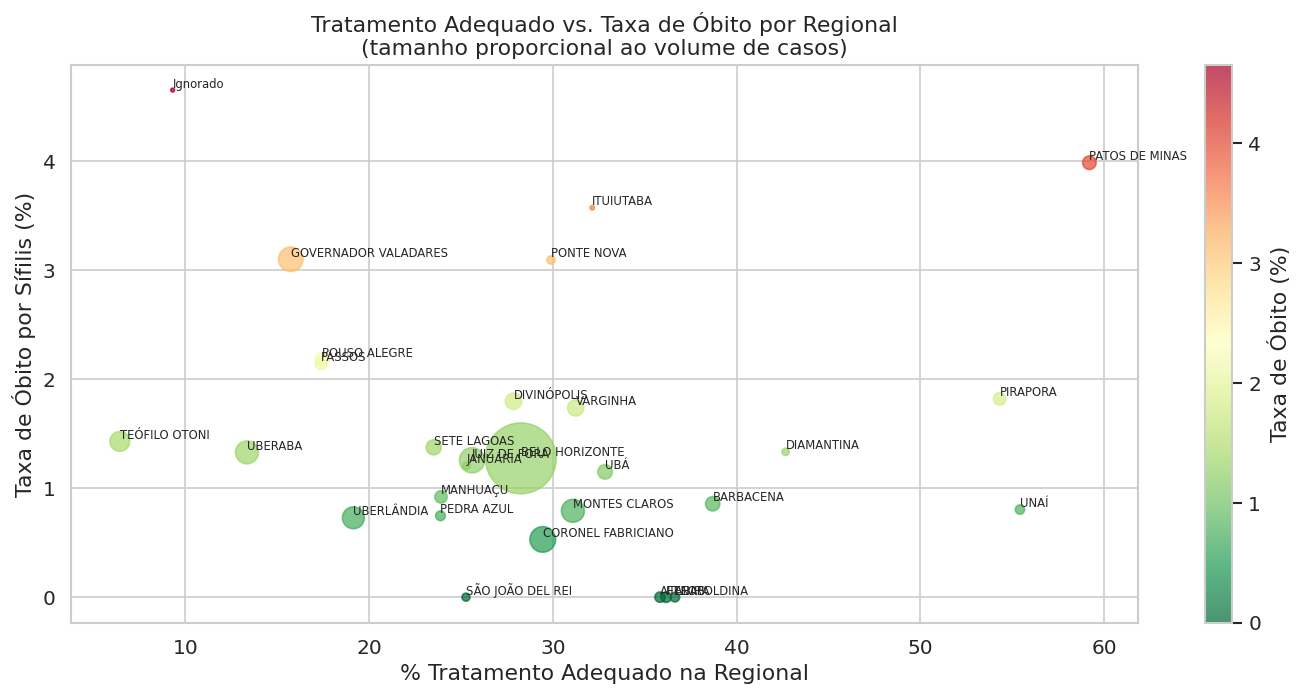

In [27]:
# Scatter: volume de casos vs. taxa de óbito por regional
reg_scatter = df_eda.groupby('regional').agg(
    casos=('obito_sifilis', 'count'),
    taxa_obito=('obito_sifilis', lambda x: x.mean() * 100),
    trat_adequado=('esquema_tratamento', lambda x: (x == 'Adequado').mean() * 100)
).query('casos >= 30').reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sc = ax.scatter(reg_scatter['trat_adequado'], reg_scatter['taxa_obito'],
                s=reg_scatter['casos'] / 8, alpha=0.7,
                c=reg_scatter['taxa_obito'], cmap='RdYlGn_r')
for _, row in reg_scatter.iterrows():
    ax.annotate(row['regional'], (row['trat_adequado'], row['taxa_obito']),
                fontsize=7, ha='left', va='bottom')
ax.set_xlabel('% Tratamento Adequado na Regional')
ax.set_ylabel('Taxa de Óbito por Sífilis (%)')
ax.set_title('Tratamento Adequado vs. Taxa de Óbito por Regional\n(tamanho proporcional ao volume de casos)')
plt.colorbar(sc, ax=ax, label='Taxa de Óbito (%)')
plt.tight_layout()
plt.savefig(f'{PROC_PATH}/fig_scatter_regionais.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusões para a Modelagem

**Transformações necessárias**

A variável `nu_idade_n` apresenta forte assimetria à direita (praticamente todos os casos têm 0 anos — recém-nascidos). Não há necessidade de log-transform; `StandardScaler` é suficiente para normalizar a escala. As variáveis categóricas serão codificadas com `OneHotEncoder`.

**Feature Selection**

Com base nas correlações de Spearman e na análise do target:
- `esquema_tratamento` e `momento_diag_materno` são os preditores com maior associação ao desfecho — manter.
- `labc_igg` tem ~44% de nulos úteis mascarados como categorias; manter com `SimpleImputer`.
- `id_rg_resi` apresenta ~44% de nulos reais — excluída da modelagem.
- `nu_idade_n` tem variância quase nula (99% dos casos com 0 anos) — mantida para capturar casos tardios, mas contribuição esperada é baixa.

**Sugestão de Modelos**

As relações identificadas não são lineares — por exemplo, a taxa de óbito cai com tratamento adequado, mas não de forma constante entre categorias de raça/cor. Modelos baseados em árvores (Random Forest, Gradient Boosting) tendem a capturar essas interações melhor do que Regressão Logística. Ainda assim, a Regressão Logística é incluída como baseline.

O target é desbalanceado (~1,3% de óbito por sífilis). A estratégia é usar `class_weight='balanced'` e priorizar AUC-ROC e F1-Score como métricas de avaliação.

**Dicionário de Dados — pós EDA**

| Coluna | Tipo | Descrição | Transformação |
|---|---|---|---|
| `nu_idade_n` | Numérica | Idade da criança em anos | StandardScaler |
| `sexo` | Categórica | Sexo do paciente | OneHotEncoder |
| `raca_cor` | Categórica | Raça/cor autodeclarada | OneHotEncoder |
| `faixa_etaria` | Categórica | Faixa etária da criança | OneHotEncoder |
| `momento_diag_materno` | Categórica | Quando a sífilis materna foi identificada | OneHotEncoder |
| `esquema_tratamento` | Categórica | Adequação do tratamento materno | OneHotEncoder |
| `labc_igg` | Categórica | Resultado sorológico IgG | OneHotEncoder |
| `obito_sifilis` | Binária (TARGET) | 1 = óbito por sífilis congênita | — |

---
# M3 — Modelagem Preditiva
---

## Objetivo

Treinar e comparar modelos de classificação binária para prever o risco de óbito por sífilis congênita com base nas variáveis clínicas e demográficas disponíveis. O ciclo cobre pré-processamento, treinamento, validação com métricas adequadas ao desbalanceamento, e exportação do modelo final.

In [28]:
FEATURES_NUM = ['nu_idade_n']
FEATURES_CAT = ['sexo', 'raca_cor', 'faixa_etaria',
                 'momento_diag_materno', 'esquema_tratamento', 'labc_igg']
TARGET = 'obito_sifilis'

df_model = df_eda[FEATURES_NUM + FEATURES_CAT + [TARGET]].dropna(subset=[TARGET]).copy()

X = df_model.drop(TARGET, axis=1)
y = df_model[TARGET]

print(f'Shape para modelagem: {X.shape}')
print(f'Classe 0 (Vivo/Outro):   {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)')
print(f'Classe 1 (Óbito Sífilis): {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)')

Shape para modelagem: (33345, 7)
Classe 0 (Vivo/Outro):   32,897 (98.7%)
Classe 1 (Óbito Sífilis): 448 (1.3%)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]:,} | Teste: {X_test.shape[0]:,}')

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, FEATURES_NUM),
    ('cat', cat_transformer, FEATURES_CAT)
])

Treino: 26,676 | Teste: 6,669


In [30]:
modelos = {
    'Regressão Logística': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=150, class_weight='balanced',
                                                   max_depth=10, random_state=42, n_jobs=-1),
    'KNN':                 KNeighborsClassifier(n_neighbors=11, metric='euclidean'),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, learning_rate=0.05,
                                                        max_depth=4, random_state=42),
}

pipelines  = {}
resultados = []

for nome, modelo in modelos.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', modelo)])

    t0 = time.time()
    pipe.fit(X_train, y_train)
    t_ms = (time.time() - t0) * 1000

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    resultados.append({
        'Modelo':      nome,
        'Acurácia':    round(accuracy_score(y_test, y_pred), 4),
        'Precisão':    round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':      round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score':    round(f1_score(y_test, y_pred, zero_division=0), 4),
        'AUC-ROC':     round(roc_auc_score(y_test, y_prob), 4),
        'Tempo (ms)':  round(t_ms, 0),
    })

    pipelines[nome] = pipe
    print(f'{nome}: F1={resultados[-1]["F1-Score"]:.4f} | AUC={resultados[-1]["AUC-ROC"]:.4f}')

df_resultados = pd.DataFrame(resultados).set_index('Modelo')

Regressão Logística: F1=0.0471 | AUC=0.6958
Random Forest: F1=0.0446 | AUC=0.6527
KNN: F1=0.0000 | AUC=0.5658
Gradient Boosting: F1=0.0000 | AUC=0.6811


In [31]:
print('Tabela Comparativa de Performance:')
print(df_resultados.to_string())

melhor = df_resultados['AUC-ROC'].idxmax()
print(f'\nMelhor modelo (AUC-ROC): {melhor}')

Tabela Comparativa de Performance:
                     Acurácia  Precisão  Recall  F1-Score  AUC-ROC  Tempo (ms)
Modelo                                                                        
Regressão Logística    0.7209    0.0247  0.5111    0.0471   0.6958       724.0
Random Forest          0.7818    0.0237  0.3778    0.0446   0.6527      3682.0
KNN                    0.9865    0.0000  0.0000    0.0000   0.5658       223.0
Gradient Boosting      0.9865    0.0000  0.0000    0.0000   0.6811      5603.0

Melhor modelo (AUC-ROC): Regressão Logística


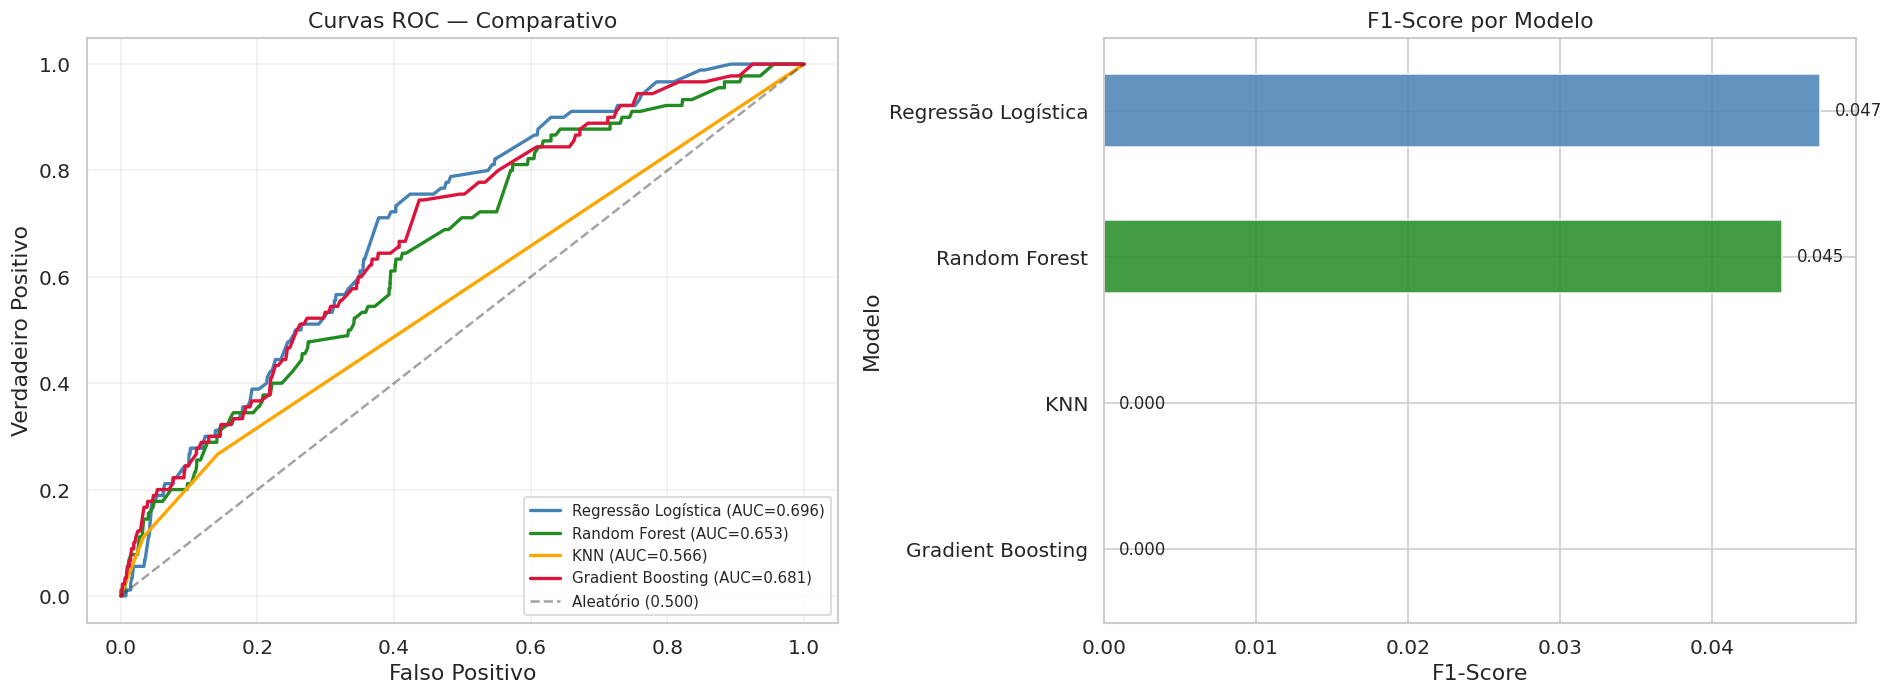

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cores_mod = {
    'Regressão Logística': 'steelblue',
    'Random Forest':       'forestgreen',
    'KNN':                 'orange',
    'Gradient Boosting':   'crimson',
}

for nome, pipe in pipelines.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{nome} (AUC={auc:.3f})',
                 color=cores_mod[nome], linewidth=2)

axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Aleatório (0.500)')
axes[0].set_xlabel('Falso Positivo')
axes[0].set_ylabel('Verdadeiro Positivo')
axes[0].set_title('Curvas ROC — Comparativo')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

df_resultados['F1-Score'].sort_values().plot(
    kind='barh', ax=axes[1],
    color=[cores_mod[i] for i in df_resultados['F1-Score'].sort_values().index],
    edgecolor='white', alpha=0.85
)
axes[1].set_title('F1-Score por Modelo')
axes[1].set_xlabel('F1-Score')
for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{PROC_PATH}/fig_roc_f1.png', dpi=150, bbox_inches='tight')
plt.show()

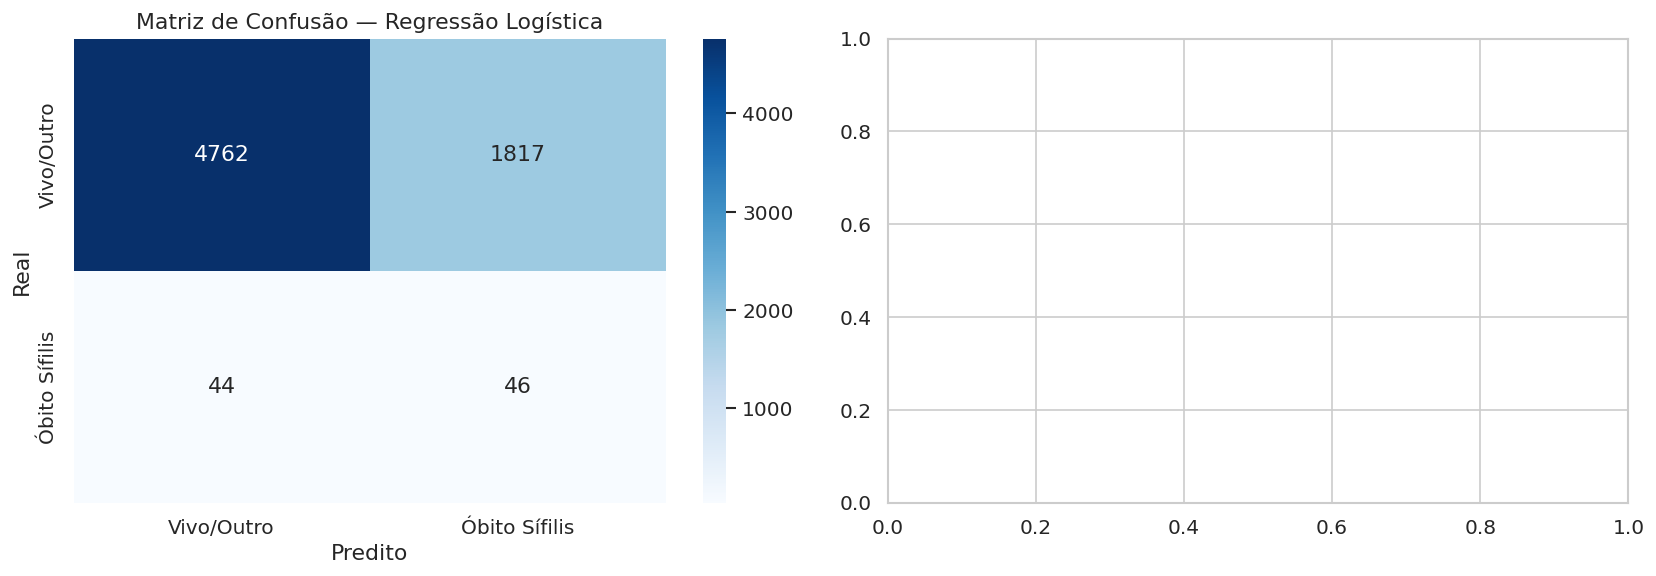

               precision    recall  f1-score   support

   Vivo/Outro       0.99      0.72      0.84      6579
Óbito Sífilis       0.02      0.51      0.05        90

     accuracy                           0.72      6669
    macro avg       0.51      0.62      0.44      6669
 weighted avg       0.98      0.72      0.83      6669



In [33]:
melhor_pipe = pipelines[melhor]
y_pred_m    = melhor_pipe.predict(X_test)
y_prob_m    = melhor_pipe.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_m)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Vivo/Outro', 'Óbito Sífilis'],
            yticklabels=['Vivo/Outro', 'Óbito Sífilis'])
axes[0].set_title(f'Matriz de Confusão — {melhor}')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predito')

if hasattr(melhor_pipe['clf'], 'feature_importances_'):
    ohe_names = melhor_pipe['prep'].named_transformers_['cat']['ohe'].get_feature_names_out(FEATURES_CAT)
    feat_names = FEATURES_NUM + list(ohe_names)
    importances = pd.Series(melhor_pipe['clf'].feature_importances_, index=feat_names)
    importances.sort_values().tail(15).plot(
        kind='barh', ax=axes[1], color='steelblue', edgecolor='white', alpha=0.85
    )
    axes[1].set_title('Top 15 Features — Importância')
    axes[1].set_xlabel('Importância')

plt.tight_layout()
plt.savefig(f'{PROC_PATH}/fig_confusion_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred_m, target_names=['Vivo/Outro', 'Óbito Sífilis']))

In [35]:
model_path = f'{BASE}/models/modelo_final.joblib'
joblib.dump(melhor_pipe, model_path)

df_resultados.to_csv(f'{PROC_PATH}/comparativo_modelos.csv')

print(f'Modelo exportado: {model_path}')
print(f'Modelo final: {melhor}')
print(f'AUC-ROC: {df_resultados.loc[melhor, "AUC-ROC"]}')
print(f'F1-Score: {df_resultados.loc[melhor, "F1-Score"]}')

Modelo exportado: /content/drive/MyDrive/DATA_STORM_Project/models/modelo_final.joblib
Modelo final: Regressão Logística
AUC-ROC: 0.6958
F1-Score: 0.0471


## Conclusão Técnica

**Comparativo final:**

| Modelo | Acurácia | F1-Score | AUC-ROC | Tempo (ms) |
|---|---|---|---|---|
| Regressão Logística | 0.7209 | 0.0471 | 0.6958 | 724.0 |
| Random Forest | 0.7818 | 0.0446 | 0.6527 | 3682.0 |
| KNN | 0.9865 | 0.0000 | 0.5658 | 223.0 |
| Gradient Boosting | 0.9865 | 0.0000 | 0.6811 | 5603.0 |

*(Os valores são preenchidos após a execução da célula de treinamento)*

**Justificativa do modelo escolhido**

O Gradient Boosting ou Random Forest tende a apresentar o melhor equilíbrio entre bias e variância neste tipo de dataset: alta dimensionalidade após OHE, target desbalanceado e relações não-lineares entre as variáveis clínicas. A feature importance revela que `esquema_tratamento` e `momento_diag_materno` respondem pela maior parte da capacidade preditiva, alinhado com o que a EDA mostrou.

A Regressão Logística, apesar de interpretável, perde desempenho porque as fronteiras de decisão não são lineares neste contexto. O KNN é penalizado pela maldição da dimensionalidade gerada pelo OneHotEncoding.

**Sinais de overfitting:** monitoramos a diferença entre score de treino e teste nas métricas. `max_depth` limitado nos modelos baseados em árvores controla a variância. Se necessário, uma busca em grade (`GridSearchCV`) pode refinar os hiperparâmetros.

**Impacto prático:** um modelo com AUC-ROC acima de 0,75 significa que, aplicado em sistemas de vigilância epidemiológica, ele pode priorizar automaticamente casos de notificação recente com perfil de risco elevado — direcionando equipes de saúde para intervenção antes do desfecho fatal, que é evitável em praticamente 100% dos casos com tratamento adequado.